In [72]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcdefaults()


### Load results

In [73]:
# Load single cell results
res_df_perf = pd.read_csv('../sc_example/results/approximation_quality.csv')
res_df_num_sig = pd.read_csv('../sc_example/results/num_sig_edges.csv')

mapper = {'nk_cells': 'NK cell', 'dc': 'Dendritic cell', 'cd8+_tcells': 'T cell (CD8+)'}
res_df_perf['dataset'] = res_df_perf['dataset'].map(mapper)
res_df_num_sig['dataset'] = res_df_num_sig['dataset'].map(mapper)

# Load GTEx results
res_df_lasso_grnboost = pd.read_csv('../../results/significant_edges_grnboost_lasso.csv')
res_df_ridge = pd.read_csv('../../results/significant_edges_ridge.csv')

print(res_df_lasso_grnboost['tissue'].unique())
print(res_df_ridge['tissue'].unique())

res_df_gtex = pd.concat([res_df_lasso_grnboost, res_df_ridge], axis=0, ignore_index=True)
mapper = {'grnboost2': 'GRNBoost2', 'lasso': 'Lasso', 'ridge': 'Ridge'}
res_df_gtex['method'] = res_df_gtex['method'].map(mapper)

res_df_gtex = (
    res_df_gtex.drop(columns=['ratio_bh', 'ratio_wy'])
    .melt(
        id_vars=['tissue', 'method', 'num_permutations'],
        value_vars=['significant_bh', 'significant_wy'],
        var_name='pval_mode',
        value_name='num_significant_edges',
    )
)

mapper = {'significant_bh': 'BH', 'significant_wy': 'WY'}
res_df_gtex['pval_mode'] = res_df_gtex['pval_mode'].map(mapper)

# Add column with number of samples
df_num_samples = pd.read_csv('../../results/random_targets_wasserstein_all_tissues_with_samples.csv', index_col=0)
tissue_to_num_samples = (
    df_num_samples.groupby('tissue')['num_samples']
    .first()
    .to_dict()
)
res_df_gtex['num_samples'] = res_df_gtex['tissue'].map(tissue_to_num_samples)
bins = [0, 500, 1000, float('inf')]
labels = ['Small', 'Medium', 'Large']
res_df_gtex['sample_bin'] = pd.cut(res_df_gtex['num_samples'], bins=bins, labels=labels, right=False)


['Adipose_Tissue' 'Adrenal_Gland' 'Bladder' 'Blood' 'Blood_Vessel' 'Brain'
 'Breast' 'Cervix_Uteri' 'Colon' 'Esophagus' 'Fallopian_Tube' 'Heart'
 'Kidney' 'Liver' 'Lung' 'Muscle' 'Nerve' 'Ovary' 'Pancreas' 'Pituitary'
 'Prostate' 'Salivary_Gland' 'Skin' 'Small_Intestine' 'Spleen' 'Stomach'
 'Testis' 'Thyroid' 'Uterus' 'Vagina']
['Bladder' 'Cervix_Uteri' 'Fallopian_Tube' 'Kidney' 'Uterus']


### Initialize Figure

In [74]:

# Set fontsize
legend_fontsize = 10

# Initialize mosaic
fig, axd = plt.subplot_mosaic(
    '''
    ABC
    XXY
    DEF
    ZZZ
    ''',
    figsize=(7.0, 4.9),
    dpi=600,
    constrained_layout=True,
    gridspec_kw={
        'height_ratios': [1, 0.05, 1, 0.05]
    }
)
plt.close(fig)

### Plot scRNA-seq results

In [75]:

# Define cmap
colors = sns.color_palette('rocket', 3)
cmap = dict(zip(sorted(res_df_perf['dataset'].unique()), colors))

# --- Plot MAE across number of permutations for fixed number of clusters
plot_df = res_df_perf[
    # (res_df_perf['num_clusters'] == 100)
    (res_df_perf['mode'] == 'raw')
    & (res_df_perf['metric'] == 'mae')
    ].copy()
ax = axd['A']
sns.lineplot(
    data=plot_df,
    x='num_permutations',
    y='score',
    hue='dataset',
    palette=cmap,
    hue_order=reversed(sorted(cmap.keys())),
    marker='o',
    ax=ax,
)
ax.set_xticks([1000, 3000, 5000, 7000, 10000])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: rf'${x / 1000:g}$')
)
ax.set_ylabel('MAE')
ax.set_xlabel(r'Permutations [$\times 10^3$]')

# --- Plot F1 across number of permutations for fixed number of clusters
alpha = 0.05
plot_df = res_df_perf[
    # (res_df_perf['num_clusters'] == 10)
    (res_df_perf['mode'] == 'raw')
    & (res_df_perf['metric'] == 'f1')
    & (res_df_perf['alpha'] == alpha)
].copy()
ax = axd['B']
sns.lineplot(
    data=plot_df,
    x='num_permutations',
    y='score',
    hue='dataset',
    palette=cmap,
    hue_order=reversed(sorted(cmap.keys())),
    marker='o',
    ax=ax,
)
ax.set_xticks([1000, 3000, 5000, 7000, 10000])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: rf'${x / 1000:g}$')
)
ax.set_ylabel(f'F1 score @ {alpha}')
ax.set_xlabel(r'Permutations [$\times 10^3$]')

# --- Plot number of significant edges depending on number of permutations
plot_df = res_df_num_sig[
    (res_df_num_sig['alpha'] == alpha)
    & (res_df_num_sig['num_clusters'] != -1)  # Exclude -1 = GT
    & (res_df_num_sig['pval_mode'].isin(['pvalue_bh', 'pvalue_westfall_young']))
].copy()

plot_df['pval_mode'] = plot_df['pval_mode'].map({'pvalue': 'raw', 'pvalue_bh': 'BH', 'pvalue_westfall_young': 'WY'})

ax = axd['C']
sns.lineplot(
    data=plot_df,
    x='num_permutations',
    y='num_sig',
    hue='dataset',
    hue_order=reversed(sorted(cmap.keys())),
    palette=cmap,
    style='pval_mode',
    markers={
        'BH': 'X',
        'WY': '^',
    },
    dashes={
        'BH': '',
        'WY': (1.5, 1.0),
    },
    ax=ax,
)
ax.set_xticks([1000, 3000, 5000, 7000, 10000])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: rf'${x / 1000:g}$')
)
ax.set_ylabel(f'Num. edges @ {alpha}')
ax.set_xlabel(r'Permutations [$\times 10^3$]')

# Plot legend A, B
handles = [
    Patch(facecolor=cmap[name], edgecolor='lightgray', linewidth=0.8, label=name)
    for name in sorted(cmap.keys())
]
ax = axd['X']
ax.legend(
    handles=handles,
    loc='center',
    frameon=False,
    fontsize=legend_fontsize,
    ncol=3,
)
ax.axis('off')

# Plot legend C
style_handles = [
    Line2D(
        [0], [0],
        color='black',
        linestyle='-',
        marker='X',
        markeredgecolor='lightgray',
        label='BH',
    ),
    Line2D(
        [0], [0],
        color='black',
        linestyle=(0, (1.5, 1.0)),
        marker='^',
        markeredgecolor='lightgray',
        label='WY',
    ),
]
ax = axd['Y']
ax.legend(
    handles=style_handles,
    fontsize=legend_fontsize,
    loc='center',
    ncol=2,
    frameon=False,
)
ax.axis('off')

for key in list('ABC'):
    axd[key].legend_.remove()
    axd[key].set_title('GRNBoost2 | scRNA-seq', fontsize=12)

### Plot GTEx results

In [76]:
# # Define cmap
# colors = sns.color_palette('Set2', 2)
# cmap = dict(zip(['BH', 'WY'], colors))
#
# for ax_key, method in zip(list('DEF'), ['GRNBoost2', 'Lasso', 'Ridge']):
#
#     plot_df = res_df_gtex[res_df_gtex['method'] == method]
#
#     ax = axd[ax_key]
#     sns.lineplot(
#         plot_df,
#         x='num_permutations',
#         y='num_significant_edges',
#         hue='pval_mode',
#         palette=cmap,
#         style='pval_mode',
#         markers={
#             'BH': 'X',
#             'WY': '^',
#         },
#         dashes={
#             'BH': '',
#             'WY': (1.5, 1.0),
#         },
#         ax=ax,
#     )
#     ax.set_xticks([1000, 3000, 5000] if method != 'Ridge' else [1000, 3000])
#     ax.xaxis.set_major_formatter(
#         FuncFormatter(lambda x, _: rf'${x / 1000:g}$')
#     )
#     if method in ['GRNBoost2', 'Lasso']:
#         ax.yaxis.set_major_formatter(
#             FuncFormatter(lambda x, _: rf'${x / 10**5:g}$')
#         )
#         ax.set_ylabel(r'Num. edges @ 0.05 [$\times 10^5$]')
#     else:
#         ax.set_ylabel(r'Num. edges @ 0.05')
#     ax.set_xlabel(r'Permutations [$\times 10^3$]')
#     ax.set_title(f'{method} | GTEx', fontsize=12)
#
# # Plot legend
# style_handles = [
#     Line2D(
#         [0], [0],
#         color=cmap['BH'],
#         linestyle='-',
#         marker='X',
#         markeredgecolor='lightgray',
#         label='BH',
#     ),
#     Line2D(
#         [0], [0],
#         color=cmap['WY'],
#         linestyle=(0, (1.5, 1.0)),
#         marker='^',
#         markeredgecolor='lightgray',
#         label='WY',
#     ),
# ]
# ax = axd['Z']
# ax.axis('off')
# ax.legend(
#     handles=style_handles,
#     fontsize=legend_fontsize,
#     loc='center',
#     ncol=2,
#     frameon=False,
# )
# for key in list('DEF'):
#     axd[key].legend_.remove()

# Define cmap
colors = sns.color_palette('rocket', 3)
cmap = dict(zip(['Small', 'Medium', 'Large'], colors))

for ax_key, method in zip(list('DEF'), ['GRNBoost2', 'Lasso', 'Ridge']):

    plot_df = res_df_gtex[res_df_gtex['method'] == method]

    ax = axd[ax_key]
    sns.lineplot(
        plot_df,
        x='num_permutations',
        y='num_significant_edges',
        hue='sample_bin',
        palette=cmap,
        style='pval_mode',
        markers={
            'BH': 'X',
            'WY': '^',
        },
        dashes={
            'BH': '',
            'WY': (1.5, 1.0),
        },
        errorbar=None,
        ax=ax,
    )
    ax.set_xticks([1000, 3000, 5000] if method != 'Ridge' else [1000, 3000])
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: rf'${x / 1000:g}$')
    )
    if method in ['GRNBoost2', 'Lasso']:
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, _: rf'${x / 10**5:g}$')
        )
        ax.set_ylabel(r'Num. edges @ 0.05 [$\times 10^5$]')
    else:
        ax.set_ylabel(r'Num. edges @ 0.05')
    ax.set_xlabel(r'Permutations [$\times 10^3$]')
    ax.set_title(f'{method} | GTEx', fontsize=12)

# Plot legend
hue_handles = [
    Patch(facecolor=cmap[name], edgecolor='lightgray', linewidth=0.8, label=name) for name in ['Small', 'Medium', 'Large']
]
style_handles = [
    Line2D(
        [0], [0],
        color='black',
        linestyle='-',
        marker='X',
        markeredgecolor='lightgray',
        label='BH',
    ),
    Line2D(
        [0], [0],
        color='black',
        linestyle=(0, (1.5, 1.0)),
        marker='^',
        markeredgecolor='lightgray',
        label='WY',
    ),
]

handles = hue_handles + style_handles

ax = axd['Z']
ax.legend(
    handles=handles,
    fontsize=legend_fontsize,
    loc='center',
    frameon=False,
    # handlelength=1.8,
    # handleheight=1.2,
    ncol=5,
)
ax.axis('off')

for key in list('DEF'):
    axd[key].legend_.remove()


### Label panels

In [77]:
for label, ax in axd.items():
    if label in list('XYZ'):
        continue
    trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
    ax.text(
        -0.25,
        1.05,
        label,
        transform=ax.transAxes + trans,
        fontsize=14,
        va='bottom',
        fontfamily='sans-serif',
        fontweight='bold'
    )


### Save Figure

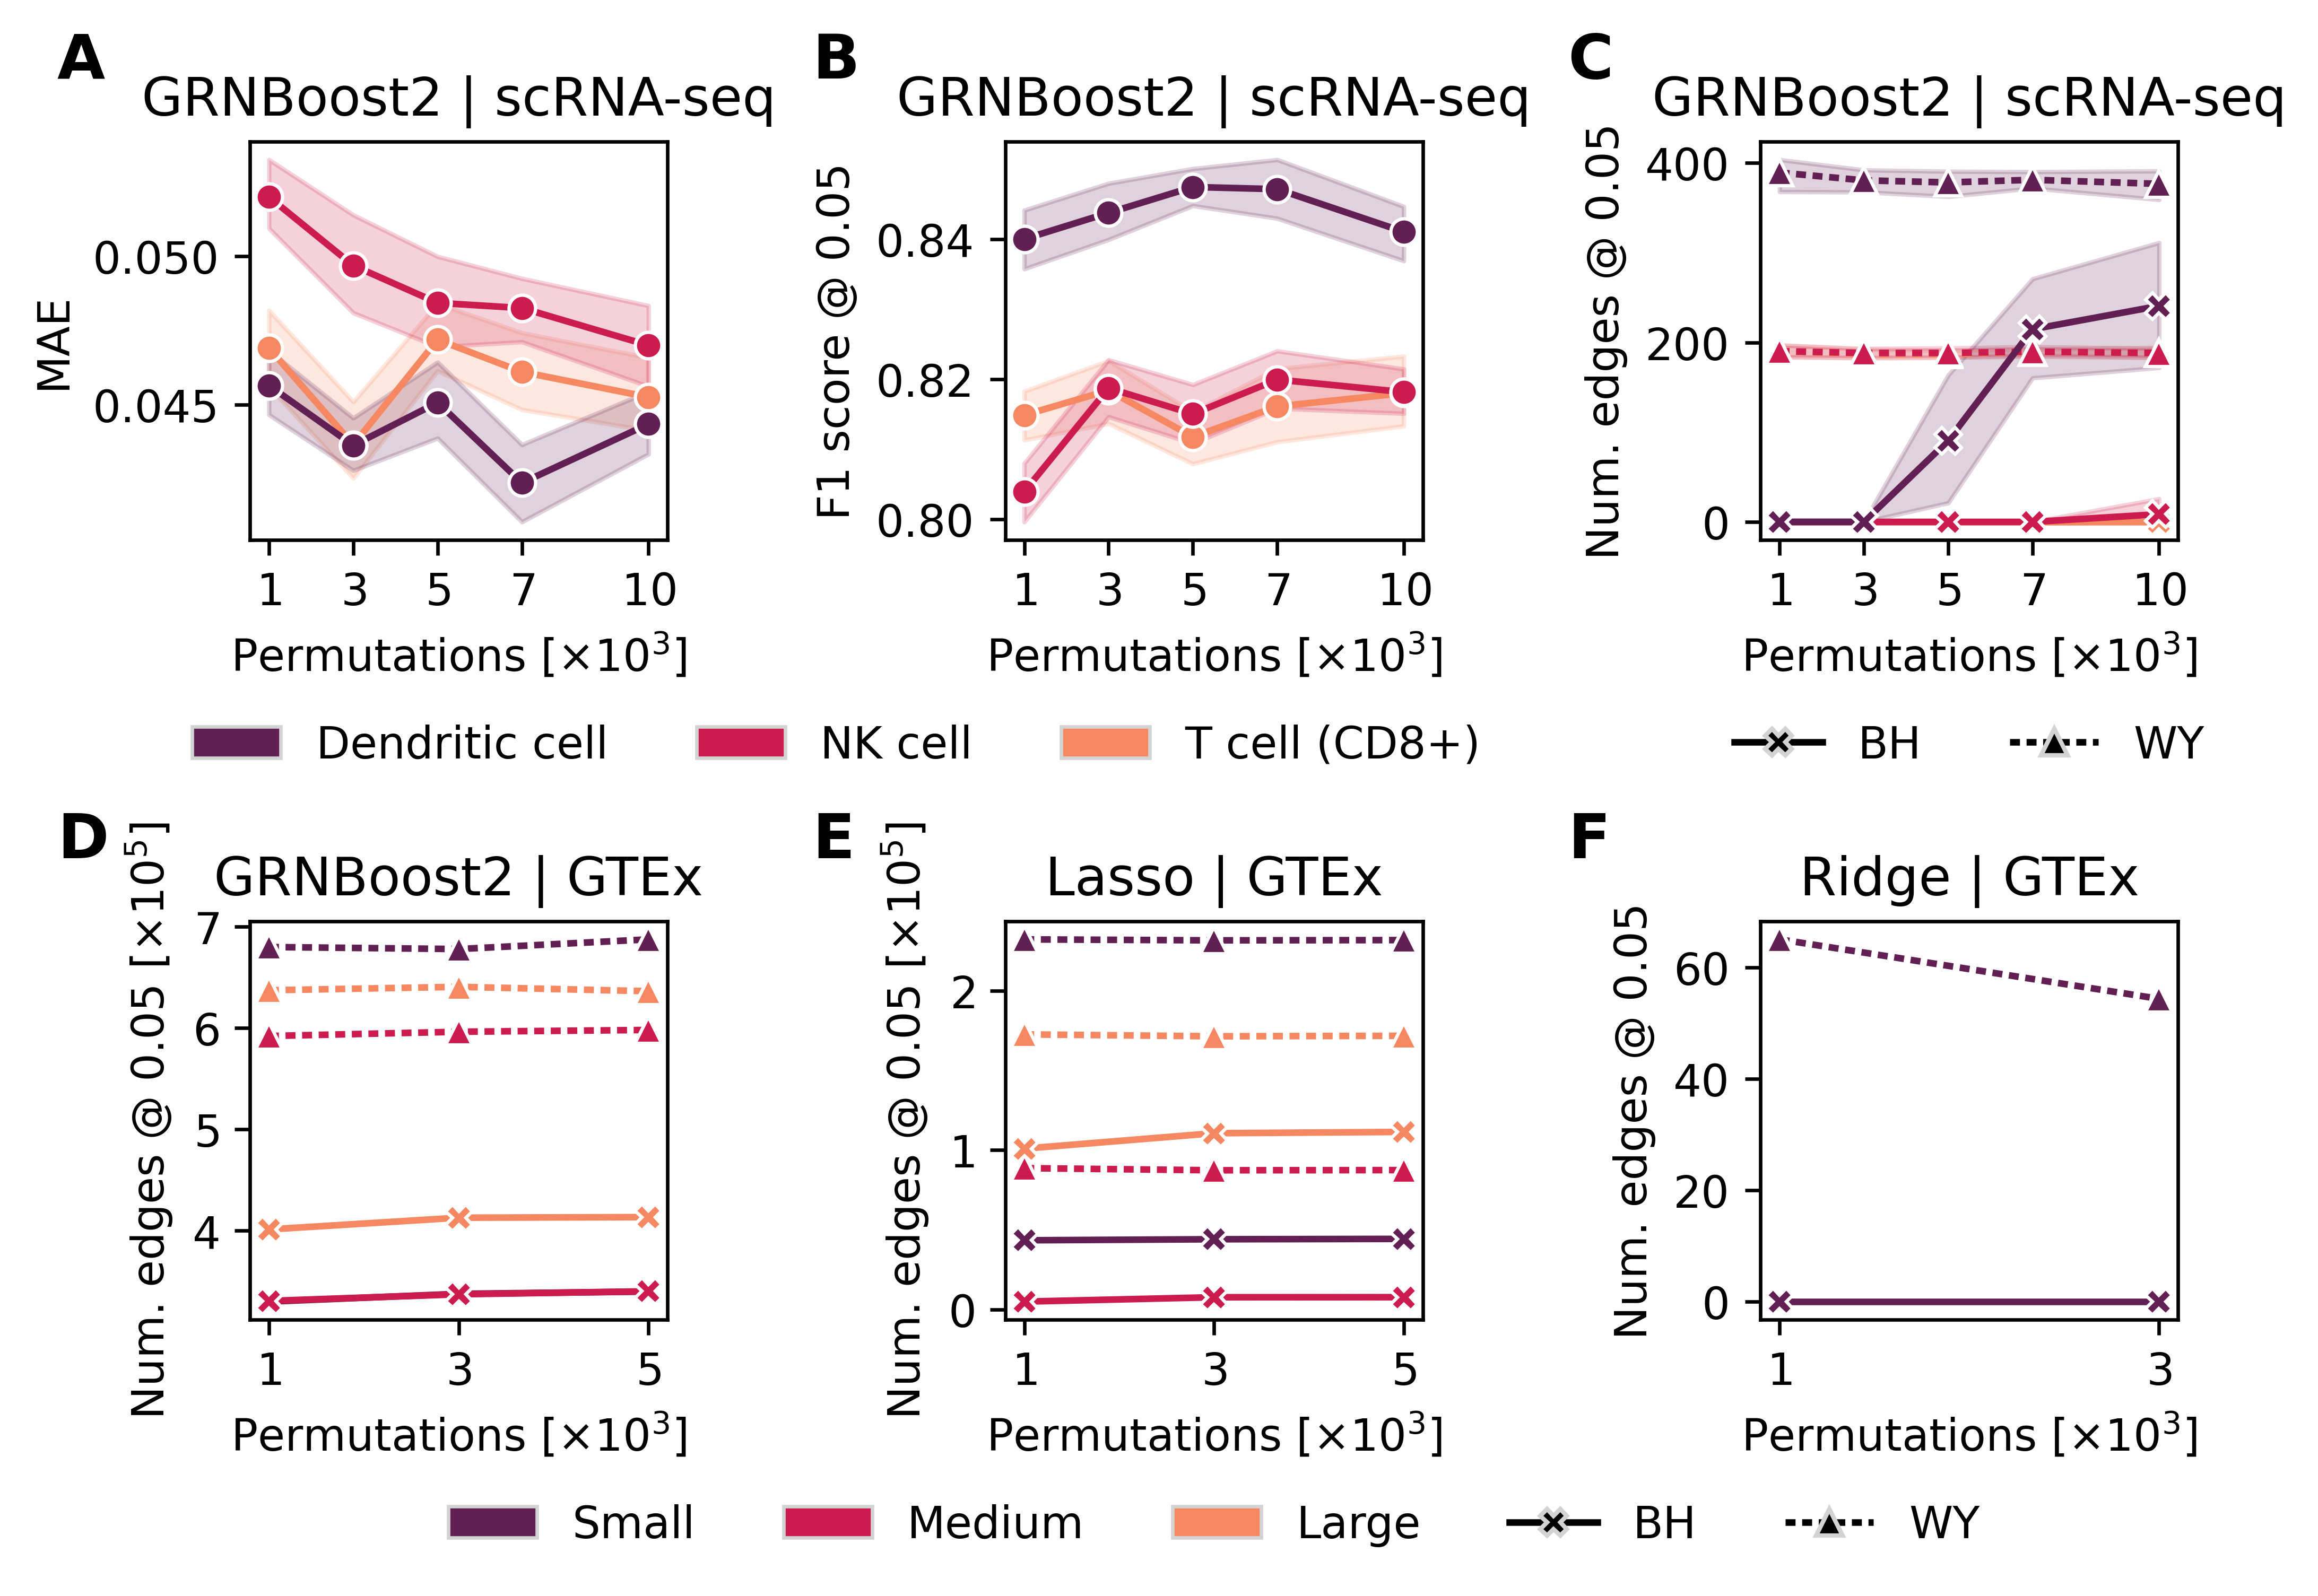

In [78]:
display(fig)
fig.savefig('supplement_num_permutations.pdf', bbox_inches='tight', dpi=fig.dpi)